<a href="{{ colab_base_laboratorios }}/Laboratorio_06_normal_equations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 6 : Ecuación normal

Se puede encontrar una solucion exacta para theta sin necesidad de emplear el gradiente descente de la sesiones pasadas, para ellos se puede encontrar el valor minimo de theta y a partir de alli determinar el valor de theta que minimiza J.

Los pasos para esta minimizacion se dejan como tarea, y pueden ser calculados según lo siguiente:

Si J es la funcion de coste dada por:

\begin{equation}
J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X - \hat{y}^{(i)})^2
\end{equation}


Demostrar que:

- $J(\theta_1,\theta_2,\theta_3, ...,\theta_n ) = \frac{1}{2m} (\Theta ^ T X - y^T) (\Theta ^ T X - y^T)^T$

- $J= (\Theta ^T X) (\Theta ^T X)^T - 2(\Theta ^T X)Y  + Y^TY $


- $ \nabla _{\theta} J = \frac{1}{m} (2 X(X^T \Theta) -2XY)$


Para encontrar el valor minimo de \theta,  $\nabla _{\theta} J = 0$,

- $\Theta = (X^T X)^{-1} X^T y$



En este caso,tenemos que:

sea $X \in R^{n\times m}$ ,  $X^T \in R^{m\times n}$

sea $Y \in R^{m \times 1}$,  $Y^T \in R^{1 \times m}$

sea $\Theta \in R^{n \times 1}$, $\Theta^T \in R^{1 \times n}$




Para la demostracion anterior emplee las siguientes propiedades:

- $z^T z= \sum_i z_i^2$
- $a^T b = b^Ta$
- $\nabla _x b^T x = b$
- $\nabla _x  x^T A x = 2Ax$

donde a, b, x son matrices, $\nabla_x$ es la derivada respecto al vector x, y A es una matriz simétrica




###DEMOSTRACION

Teniendo en cuenta la forma de la funcion de coste y la primera propiedad de utilidad veamos que:

$$J(\theta_1,\theta_2,\theta_3, ...,\theta_n )=\frac{1}{2m} \sum_{i = 1}^m (\Theta^{T} X - \hat{y}^{(i)})^2 = \frac{1}{2m}(\Theta^T X - Y^T)(\Theta^T X - Y^T)^T$$

---

Si introducimos en el último paréntesis la transposición y realizamos el producto, se obtiene la siguiente expresión:

$$J(\theta) = \frac{1}{2m}((\Theta^T X) (\Theta^T X)^T - (\Theta^T X) Y - Y^T (\Theta^T X)^T + Y^T Y )$$

---

Como $\Theta^T X$ y $Y$ son vectores // matrices $(1\times m)$ y $(m \times 1)$ respectivamente, se puede emplear la propiedad para los productos punto de dos vectores $a^T b = b^T a$, es decir, se tiene que $\Theta^TX Y = Y^T (\Theta^T X)^T$. Además, usando que $(AB)^T = B^T A^T$, la expresión se puede simplificar de la siguiente forma:

$$J(\theta) = \frac{1}{2m}(\Theta^T X X^T \Theta - 2Y^T X^T \Theta + Y^T Y )$$

---

Empleando las propiedades siguientes $\nabla _x b^T x = b$ y $\nabla _x  x^T A x = 2Ax$ calculemos el gradiente $\nabla_\theta J$ con respecto a los parámetros $\theta$, Asi:

 $$\nabla_\theta J=  \frac{1}{2m} (\nabla_\theta (\Theta^T (X X^T) \Theta) -2  \nabla_\theta ((Y^T X^T) \Theta) )$$

  $$\nabla_\theta J=  \frac{1}{2m} (  2XX^T\Theta - 2XY ) =\frac{1}{m} (  XX^T\Theta - XY )  $$

---

Para encontrar el punto extremo se iguala a cero la anterior expresion lo que finalmente da como resultado:

$$  XX^T\Theta - XY  = 0 $$

$$\Theta = (XX^T)^{-1}XY$$

---



In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
import pandas as pd

1. Para los datos del laboratorio anterior aplicar la ecuacion normal.

In [4]:
# Datos del laboratorio anterior

# Número de muestras (puntos de datos)
N = 100

# Generación de las dos variables independientes x₁ y x₂ en el rango [-1, 1]
x_1=2*np.random.random(N)-1
x_2=2*np.random.random(N)-1

# Cálculo de la variable dependiente (etiqueta)
y_label=2.1*x_1-3.1*x_2

df=pd.DataFrame({"x1":x_1, "x2":x_2, "y":y_label})

df

,x1,x2,y
0,0.676099,0.271334,0.578674
1,-0.353920,-0.284933,0.140059
2,-0.275562,0.024018,-0.653136
3,0.146958,-0.910030,3.129704
4,0.640230,-0.694899,3.498668
...,...,...,...
95,-0.550888,0.163464,-1.663603
96,-0.920301,-0.799730,0.546533
97,0.463531,-0.255636,1.765886
98,-0.864010,0.419279,-3.114186


In [5]:
def theta(X, Y):
    """
    Calcula los parámetros óptimos del modelo de regresión lineal utilizando la ecuación normal.

    Parámetros:
    -----------
    X : ndarray (shape = (n+1, m))
        Matriz de características, donde cada columna representa una muestra.
    Y : ndarray (shape = (1, m))
        Valores reales de salida (etiquetas verdaderas).

    Retorna:
    --------
    theta_opt : ndarray (shape = (n+1, 1))
        Vector de parámetros óptimos del modelo.
    """
    # Cálculo de θ utilizando la ecuación normal: θ = ((X·Xᵀ)⁻¹·X·Yᵀ)ᵀ
    theta_opt = (np.linalg.inv(X @ X.T) @ X @ Y.T).T
    return theta_opt

In [7]:
# Número de datos de entrenamiento
m=N

# Características (2: x_1, x_2)
n=2

X=np.zeros((n+1,m))
X[0,:]=1
X[1,:]=df['x1']
X[2,:]=df['x2']
#print(np.shape(X))
X
Y = df['y'].values.reshape(1, -1)
theta(X, Y)

array([[ 1.11022302e-16,  2.10000000e+00, -3.10000000e+00]])

# **¡¡Al aplicar el metodo de la ecuación normal se obtuvieron los mismos resultados que mediante el método del gradiente descendente!!**


2. Tomar el dataset de las casas de Boston y construir un modelo de regresión mutivariada.

```
# Tomar los datos de las casas de boston y hacer una regresion lineal tomando
# el average number of rooms per dwelling.
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

df = pd.DataFrame({"mean_":target, "rm":data[:,5]})

```

In [46]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Dataset de Boston
columns = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT"
]

df_full = pd.DataFrame(data, columns=columns)
df_full["PRICE"] = target

# Variables explicativas y variable objetivo
X = df_full.drop(columns=["PRICE"])
y = df_full["PRICE"]

# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Entrenar modelo
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Predicciones
y_pred_train = model_multi.predict(X_train)
y_pred_test = model_multi.predict(X_test)

# Métricas
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

# Coeficientes
coef_df = pd.DataFrame({
    "Variable": ["Intercept"] + list(X.columns),
    "Coeficiente": [model_multi.intercept_] + list(model_multi.coef_)
})

print("-" * 50)
print("Modelo multivariado con train/test")
print(f"MSE entrenamiento: {mse_train:.2f}")
print(f"MSE prueba: {mse_test:.2f}")
print(f"R² entrenamiento: {r2_train:.3f}")
print(f"R² prueba: {r2_test:.3f}")
print("-" * 50)

coef_df

--------------------------------------------------
Modelo multivariado con train/test
MSE entrenamiento: 21.64
MSE prueba: 24.29
R² entrenamiento: 0.751
R² prueba: 0.669
--------------------------------------------------


,Variable,Coeficiente
0,Intercept,30.246751
1,CRIM,-0.113056
2,ZN,0.030110
3,INDUS,0.040381
4,CHAS,2.784438
5,NOX,-17.202633
6,RM,4.438835
7,AGE,-0.006296
8,DIS,-1.447865
9,RAD,0.262430


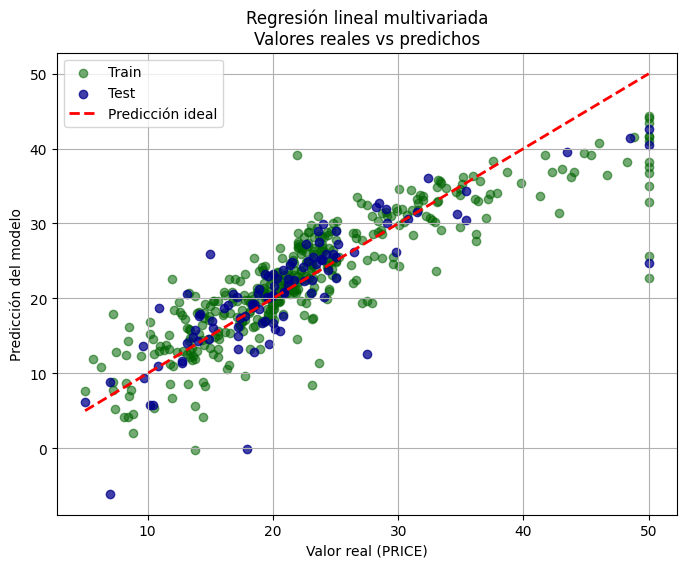

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(y_train, y_pred_train, color="darkgreen", alpha=0.55, label="Train")
plt.scatter(y_test, y_pred_test, color="darkblue", alpha=0.75, label="Test")

min_val = min(y_train.min(), y_test.min())
max_val = max(y_train.max(), y_test.max())

plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2, label="Predicción ideal")

plt.xlabel("Valor real (PRICE)")
plt.ylabel("Predicción del modelo")
plt.title("Regresión lineal multivariada\nValores reales vs predichos")
plt.grid(True)
plt.legend()
plt.show()

---

# Intepretación Probabilistica.

Supongamos que tenemos una caracteristica $x_i$ con m valores de entrenamiento, si asumimos que cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$, cada $y_i$ podrá tener el siguiente valor:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo ademas que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Escribiendo, lo anterior en terminos de la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ parametrizado por $\theta$ obtenemos que:


\begin{equation}
p_i(y^{i}|x^{i};\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}



Si ausmimos independencia estadística de cada $\epsilon^{(i)}$, la probabilidad $L(\theta)$ asociada a toda la distribución de puntos viene dada por:

\begin{equation}
\cal{L}(\theta) = p(\vec{y}|X;\theta)=\prod_{i=1}^{n} p_i(y^{i}|x^{i};\theta)
\end{equation}



\begin{equation}
\cal{L}(\theta) =\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}

para tener la mejor estimación posible de los valores que se deben elegir de  $\theta$, se escogeran los parámetros que generan la mayor probabilidad de ocurrencia según las observaciones, es decir, aquellos valores para el cual $L(\theta)$ es máximo, si aplicamos el logaritmo natural antes de máximar tenemos que:

\begin{equation}
\ln \cal{L}(\theta) = \cal{l}(\theta) = \ln \left[\prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}} \right]
\end{equation}


Después de un par de pasos se puede encontrar que:

\begin{equation}
\cal{l}(\theta) = n\ln \frac{1}{\sqrt{2\pi\sigma}} - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^{i}-\Theta^T X^{i})^2
\end{equation},

maximar $\cal{l(\theta)}$ equivale a encontrar donde  $\nabla_{\theta} \cal{l(\theta)} = 0$. Lo anterior muestra por que la elección de minimos cuadrados puede ser una buena eleccción para el analisis de los datos.

# Intepretación Probabilistica de la regularizacion.

Supongamos adicionalmente que el vector de parámetros $\theta$ también es aleatorio, es decir es un vector de variables aleatorias, con lo cual incluiríamos entonces toda la aleatoriedad posible que pueden tener los mecanismos del sistema que estamos estudiando. La distribución de $\theta$ es también una normal en función de la norma de $\theta$:

\begin{equation}
p(\theta)=\frac{1}{\sqrt{2\pi\tau}} e^{-\frac{ \left| \theta \right|^2 }{2 \tau ^2}}
\end{equation}

Tenemos como en el caso anterior que tanto las caracteristicas x como y son variables aleatorias y que si tenemos una caracteristica $x_i$ cada valor $y_i$ presenta una dispersión gaussiana $\epsilon_i$:

$y^{i} = \Theta^T X^{(i)} + \epsilon_i$

Asumiendo de nuevo que el ruido gaussiando es aleatorio y esta distribuido de forma identica, con media cero y varianza $\sigma$, tenemos que la probabilidad de que la cantidad y tenga  dispersion $\epsilon_i$ es:
\begin{equation}
p(\epsilon^{(i)})=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( \epsilon^{(i)}\right)^2 }{2\sigma ^2}}
\end{equation}

Ahora por la ley de Bayes podemos expresar la probabilidad de $\theta$ dados los datos $X$ y $y$ y preguntarmos por los valores de $\theta$ que maximizan la probabilidad.

\begin{equation}
p(\theta | X, y) = \frac{p(X,y | \theta) p(\theta)} {p(X,Y)}
 = \frac{P(y | X, \theta) p(\theta)}{p(Y|X)}
\end{equation}
donde asumimos la independencia de $X$ de $\theta$ con la propiedad $p(X|\theta)=p(X)$

El máximo de la probabilidad se obtiene maximizando el nominador pues el denominador no depende de $\theta$. Estos parámetros que se obtienen por este método se denominan Maximum a Posteriori MAP. Note que la expresión es la misma anterior excepto que ahora está multiplicada por la probabilidad de $\theta$

Igualmente tenemos la probabilidad de obtener un valor de $y^{i}$ dado un $x^{i}$ y un $\theta$ dados por:


\begin{equation}
p_i(y^{i}|x^{i},\theta)=\frac{1}{\sqrt{2\pi\sigma}} e^{-\frac{ \left( y_i - \Theta^T X^{(i)} \right)^2 }{2\sigma ^2}}
\end{equation}
